# Tutorial: Meta (Catalog)-based Real/Bogus Classification

This tutorial shows how to load a pre-trained ensemble model and run Real/Bogus inference  
using **35 morphological/photometric features** extracted from SExtractor + PSFEx catalogs.

| Label | Meaning |
|-------|---------|
| **Real (1)** | Genuine astrophysical transient |
| **Bogus (0)** | Subtraction artifact, cosmic ray, etc. |

> **Kernel**: activate the `rbc` conda environment before running  
> (`conda activate rbc`, then open Jupyter)

---
## 0. Setup

In [16]:
import os, sys, glob, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')   # run from notebook/
sys.path.insert(0, PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')

Project root: /lyman/data1/rb_classification_meta


In [17]:
# ── Choose model version ──────────────────────────────────────────────────────
MODEL_VERSION = 'm1_rf_baseline'   # see performance table below

META_OUTPUT_DIR  = os.path.join(PROJECT_ROOT, 'output', 'meta')
STACKED_META_DIR = os.path.join(PROJECT_ROOT, 'data', 'stacked_meta')
SUMMARY_CSV      = os.path.join(PROJECT_ROOT, 'output', 'summary', 'compare_results.csv')

MODEL_DIR = os.path.join(META_OUTPUT_DIR, MODEL_VERSION)
for fname in ['model.pkl', 'features.json', 'imputer.pkl', 'scaler.pkl', 'metrics.json']:
    path = os.path.join(MODEL_DIR, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing: {path}')

print(f'Model directory: {MODEL_DIR}')

Model directory: /lyman/data1/rb_classification_meta/output/meta/m1_rf_baseline


---
## 1. Pre-computed Performance

All models were trained on 7DT meta-catalogs (tile-based split).  
The numbers below are stored results — **no recomputation needed**.

In [18]:
summary = pd.read_csv(SUMMARY_CSV)
meta_cols = ['version', 'model_type', 'auroc', 'f1_macro', 'accuracy', 'f1_real', 'f1_bogus']
meta_perf = (
    summary[summary['pipeline'] == 'meta'][meta_cols]
    .dropna(subset=['auroc'])
    .sort_values('auroc', ascending=False)
    .reset_index(drop=True)
)
meta_perf.columns = ['Version', 'Model', 'AUROC', 'F1-macro', 'Accuracy', 'F1-Real', 'F1-Bogus']
meta_perf

,Version,Model,AUROC,F1-macro,Accuracy,F1-Real,F1-Bogus
0,test_fix,xgb,0.997372,0.978991,0.979000,0.979432,0.978550
1,smoke_test_meta_redesign,rf,0.993416,0.964974,0.965000,0.965920,0.964029
2,m1_cat_gpu,cat,0.985837,0.973941,0.989848,0.994301,0.953582
3,m1_xgb_tuned,xgb,0.984665,0.972680,0.989326,0.994005,0.951355
4,m1_lgbm_cpu,lgbm,0.983527,0.973373,0.989596,0.994157,0.952589
5,m1_rf_baseline,rf,0.982874,0.975132,0.990303,0.994555,0.955708
6,smoke_test_rf,rf,0.982874,0.975132,0.990303,0.994555,0.955708
7,m1_mlp_gpu,mlp,0.975555,0.973434,0.989639,0.994182,0.952687
8,test_fix_v2,mlp,0.169860,0.333333,0.500000,0.666667,0.000000
9,test_gpu_mlp,mlp,0.169860,0.333333,0.500000,0.666667,0.000000


---
## 2. Load Model & Preprocessing Objects

Three files are required alongside the model:

| File | Purpose |
|------|---------|
| `model.pkl` | Trained classifier (RandomForest / XGBoost / etc.) |
| `features.json` | Ordered list of 35 input feature names |
| `imputer.pkl` | Median imputer fitted on training data |
| `scaler.pkl` | StandardScaler fitted on training data |

In [19]:
with open(os.path.join(MODEL_DIR, 'model.pkl'),    'rb') as f: model   = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'imputer.pkl'),  'rb') as f: imputer = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'scaler.pkl'),   'rb') as f: scaler  = pickle.load(f)
with open(os.path.join(MODEL_DIR, 'features.json'))      as f: feature_names = json.load(f)
with open(os.path.join(MODEL_DIR, 'metrics.json'))       as f: stored_metrics = json.load(f)

print(f'Model type  : {type(model).__name__}')
print(f'Features    : {len(feature_names)}')
print(f'Stored metrics: {stored_metrics}')

Model type  : RandomForestClassifier
Features    : 35
Stored metrics: {'f1_macro': 0.9751319640189554, 'f1_real': 0.9945554764789729, 'f1_bogus': 0.9557084515589379, 'auroc': 0.9828743368353967, 'accuracy': 0.9903029584863925}


---
## 3. Input Feature Overview

The 35 features are engineered from SExtractor and PSFEx catalogs by `script/03_Stack_Catalogs.py`.

In [20]:
groups = {
    'Shape (ellipse moments)' : ['CXX_IMAGE','CYY_IMAGE','CXY_IMAGE','THETA_IMAGE','XY_IMAGE'],
    'Quality flag'            : ['FLAGS'],
    'Isophotal flux ratios'   : [f for f in feature_names if f.startswith('RATIO_ISO')],
    'Position distances'      : [f for f in feature_names if f.startswith('DIST')],
    'Size ratios'             : [f for f in feature_names if 'RADIUS' in f or 'FWHM' in f],
    'Flux ratios'             : [f for f in feature_names if 'FLUX_MAX' in f],
    'Normalized shape'        : [f for f in feature_names if any(k in f for k in
                                  ['ELONGATION','ELLIPTICITY','X2_IMAGE','Y2_IMAGE'])],
}
for group, cols in groups.items():
    if cols:
        print(f'[{group}]  ({len(cols)} features)')
        print('   ' + ',  '.join(cols))
        print()

[Shape (ellipse moments)]  (5 features)
   CXX_IMAGE,  CYY_IMAGE,  CXY_IMAGE,  THETA_IMAGE,  XY_IMAGE

[Quality flag]  (1 features)
   FLAGS

[Isophotal flux ratios]  (8 features)
   RATIO_ISO1_ISO0,  RATIO_ISO2_ISO0,  RATIO_ISO3_ISO0,  RATIO_ISO4_ISO0,  RATIO_ISO5_ISO0,  RATIO_ISO6_ISO0,  RATIO_ISO7_ISO0,  RATIO_ISO_FLUX_MAX

[Position distances]  (4 features)
   DIST,  DIST_PSF,  DIST_PSF.mask,  DIST_WIN

[Size ratios]  (5 features)
   RATIO_KRON_RADIUS_FWHM_IMAGE,  RATIO_PETRO_RADIUS_FWHM_IMAGE,  RATIO_FLUX_RADIUS_FWHM_IMAGE,  RATIO_FWHMPSF_IMAGE_FWHM_IMAGE,  RATIO_FWHMPSF_IMAGE_FWHM_IMAGE.mask

[Flux ratios]  (5 features)
   RATIO_ISO_FLUX_MAX,  RATIO_AUTO_FLUX_MAX,  RATIO_PETRO_FLUX_MAX,  RATIO_PSF_FLUX_MAX,  RATIO_PSF_FLUX_MAX.mask

[Normalized shape]  (8 features)
   RATIO_ELONGATION,  RATIO_ELONGATION.mask,  RATIO_ELLIPTICITY,  RATIO_ELLIPTICITY.mask,  RATIO_X2_IMAGE,  RATIO_X2_IMAGE.mask,  RATIO_Y2_IMAGE,  RATIO_Y2_IMAGE.mask



---
## 4. Inference Demo

### Input
A row (or a batch of rows) from a feature-engineered parquet file  
(`real_ml.parquet` or `bogus_ml.parquet` produced by `script/03_Stack_Catalogs.py`).

### Output
`rb_score` ∈ [0, 1] — probability of being **Real**.  
Apply a threshold (default 0.5) to get a binary label.

```
parquet row  →  imputer  →  scaler  →  model  →  rb_score  →  label
```

In [21]:
def predict(model, df, feature_names, imputer, scaler, threshold=0.5):
    """
    Parameters
    ----------
    df            : pandas DataFrame containing the 35 feature columns
    feature_names : list of str   — ordered feature names (from features.json)
    imputer       : fitted SimpleImputer  (from imputer.pkl)
    scaler        : fitted StandardScaler (from scaler.pkl)
    threshold     : float — classification threshold (default 0.5)

    Returns
    -------
    rb_score : numpy array (N,)  — Real probability
    label    : numpy array (N,)  — 1=Real, 0=Bogus
    """
    X        = imputer.transform(df[feature_names].values)
    X        = scaler.transform(X)
    rb_score = model.predict_proba(X)[:, 1]
    label    = (rb_score >= threshold).astype(int)
    return rb_score, label

In [22]:
# Load 5 Real and 5 Bogus rows from the first tile as demo samples
tile_dir  = sorted(glob.glob(os.path.join(STACKED_META_DIR, 'T*')))[0]
df_real   = pd.read_parquet(os.path.join(tile_dir, 'real_ml.parquet')).head(5)
df_bogus  = pd.read_parquet(os.path.join(tile_dir, 'bogus_ml.parquet')).head(5)

real_scores,  real_labels  = predict(model, df_real,  feature_names, imputer, scaler)
bogus_scores, bogus_labels = predict(model, df_bogus, feature_names, imputer, scaler)

print(f'Tile: {os.path.basename(tile_dir)}')
print(f'Real  rb_scores : {np.round(real_scores,  4)}')
print(f'Bogus rb_scores : {np.round(bogus_scores, 4)}')

Tile: T00138
Real  rb_scores : [0.99 1.   1.   1.   1.  ]
Bogus rb_scores : [0. 0. 0. 0. 0.]


In [23]:
# Build a results DataFrame for inspection
df_real ['true_label'] = 1
df_bogus['true_label'] = 0
df_demo = pd.concat([df_real, df_bogus], ignore_index=True)

rb_score, label = predict(model, df_demo, feature_names, imputer, scaler)
df_demo['rb_score'] = rb_score
df_demo['predicted_label'] = label
df_demo['correct'] = df_demo['predicted_label'] == df_demo['true_label']

# Show feature columns + output side by side
display_cols = feature_names[:5] + ['rb_score', 'predicted_label', 'true_label', 'correct']
df_demo[display_cols]

,CXX_IMAGE,CYY_IMAGE,CXY_IMAGE,THETA_IMAGE,XY_IMAGE,rb_score,predicted_label,true_label,correct
0,0.109459,0.107627,-0.002486,63.20,0.105506,0.99,1,1,True
1,0.224069,0.199392,-0.020981,69.81,0.235382,1.00,1,1,True
2,0.129754,0.120380,-0.011416,64.70,0.366191,1.00,1,1,True
3,0.263562,0.221216,-0.013434,81.20,0.115300,1.00,1,1,True
4,0.113497,0.115288,-0.004759,34.69,0.181917,1.00,1,1,True
5,0.144228,0.172649,-0.035879,25.81,0.729877,0.00,0,0,True
6,0.152465,0.158537,0.005734,-21.68,-0.118654,0.00,0,0,True
7,0.119122,0.074603,0.043740,-67.75,-2.600887,0.00,0,0,True
8,0.160018,0.128756,0.154576,-50.72,-5.282919,0.00,0,0,True
9,0.315873,0.151577,-0.236797,62.38,3.496623,0.00,0,0,True


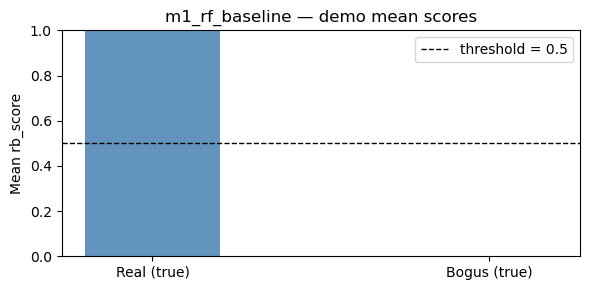

In [24]:
# Score distribution of the demo
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(['Real (true)',  'Bogus (true)'],
       [real_scores.mean(), bogus_scores.mean()],
       color=['steelblue', 'tomato'], alpha=0.85, width=0.4)
ax.axhline(0.5, ls='--', color='k', lw=1, label='threshold = 0.5')
ax.set_ylabel('Mean rb_score')
ax.set_ylim(0, 1)
ax.set_title(f'{MODEL_VERSION} — demo mean scores')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Applying to Your Own Data

Provide a DataFrame with the 35 feature columns — no labels needed.

```python
# From a parquet file produced by script/03_Stack_Catalogs.py
df_new = pd.read_parquet('path/to/my_tile/real_ml.parquet')
rb_score, label = predict(model, df_new, feature_names, imputer, scaler)
```

### Preprocessing pipeline (applied inside `predict()`)

```
raw feature values
    → SimpleImputer  (fills NaN with training-set medians)
    → StandardScaler (zero-mean, unit-variance from training data)
    → model.predict_proba()[:, 1]
    → rb_score
```

> The `imputer` and `scaler` are fitted on the **training data** and saved to disk.  
> Always reuse them — do **not** refit on new data.

### Pre-trained model options

| `MODEL_VERSION` | Model | AUROC |
|-----------------|-------|-------|
| `m1_cat_gpu` | CatBoost | 0.9858 |
| `m1_rf_baseline` | RandomForest | 0.9829 |
| `m1_xgb_tuned` | XGBoost | 0.9847 |
| `m1_lgbm_cpu` | LightGBM | 0.9835 |